<p align="center">
<img src="../img/lvra.png" alt="drawing" width="100"/>
</p>
<h1 align="center">  Lasair Features Descriptions: latestPairColourTemp </h1>


---

## What you'll learn

- How the feature `latestPairColourTemp` in Lasair is calculated

### Background

The LSST strategy will produce at least two visits for each patch of sky with two different filters. We can use the colour information to estimate a **Black Body Colour Temperature**.

To do this we need to:
1. Get the E(B-V) at the target location is.
2. Know the filter dependent extinction correction is (for a chosen $R_V$)
3. Calculate the flux ratio
4. Correct that flux ratio for extinction
5. Fit the Black Body curve. 


## Pre-requesites
### **Have you got a Lasair Token?**

**_Why do I need a token to stream public alerts?_** Because without authentication systems, bad actors can mess with our servers. But creating a Lasair profile is **Free and Public** for everyone. You can do this on the [Lasair Platform](http://lasair.lsst.ac.uk/) (go to Sing-In page).

Then you will be able to **see and copy your token** from your [profile](http://lasair.lsst.ac.uk/profile) page. 

**You should not share your token or save it in public repositories e.g. GitHub**.  One of the easies things to do so you don't have to keep pasting it, is to save it on your local machine in your shell environment. For example add this to your `bashrc` or `bash_profile`

```bash
export LASAIR_LSST_TOKEN=blablablablablYOUROTKENHEREblablabla
```

### **Have you installed the `lasair` client ?**

You can do this through pip!

```bash
pip install lasair
```



----

<h2 align="center">  1. Extinction Corrections </h2>

### Get E(B-V) for the alert



In [25]:
from lasair import lasair_client as lapi
import os
import numpy as np


In [3]:
API_TOKEN = os.getenv('LASAIR_LSST_TOKEN')

if API_TOKEN is None:
    print("No Token found. Check Spelling. Note that if you have just added your token to your environment variables, you may need to restart your terminal so your shell settings are reloaded. ")

In [4]:
# first let's get a pair and ebv from a known source
L = lapi(API_TOKEN, 
         endpoint='https://api.lasair.lsst.ac.uk/api'
         )

In [5]:
result = L.object(313761043604045880, 
                  lasair_added=True)

In [14]:
result['lasairData']['ebv']

0.0127092

In [31]:
ebv = result['lasairData']['ebv']

_How Did you get that E(B-V)?_

We use the [Schlafly and Finkbeiner ](https://iopscience.iop.org/article/10.1088/0004-637X/737/2/103) corrections. If you have ever used the `dustmaps` python package, that is the `SFD` object, 

In this example I don't make us run `dustmaps` because the dependency comes with heavy dust extinction maps (a heavy dependecy for a lesson). If you already have the dustmaps package feel free to run it to double check! You can get the ra and dec using:

```python
result['diaObject']['ra'], result['diaObject']['decl']
```

### Reddening

For that we need our $R_V$ factor, which is **filter dependent**. For a standard $R_V$ factor of 3.1, we have the following **reddening  factors** (see Table 6 - [Schlafly and Finkbeiner 2011](https://iopscience.iop.org/article/10.1088/0004-637X/737/2/103)

In [29]:
## Reddening dictionary
Rv_3p1_dict = {'u': 4.145, 'g': 3.237, 'r': 2.273, 'i': 1.684, 'z': 1.323, 'y': 1.088}
lsst_band_wl = {'u': 0.380, 'g': 0.500, 'r': 0.620, 'i': 0.740, 'z': 0.880, 'y': 1.000}


<h2 align="center">  2. Get our flux values and calculate flux ratio </h2>

### Let's grab a colour pair 

**NOTE!: If you run this at a later date you will get a different result, below I will hard code the values of flux and the filters so the solver part does not change. Feel free to play with it**

In [22]:
result['diaSourcesList'][0:2]

[{'diaSourceId': 170076864185892879,
  'midpointMjdTai': 61101.07548563987,
  'band': 'g',
  'psfFlux': 75368.203125,
  'psfFluxErr': 460.0452880859375,
  'reliability': 1.0},
 {'diaSourceId': 170076861628940326,
  'midpointMjdTai': 61101.03097964759,
  'band': 'i',
  'psfFlux': 110267.0859375,
  'psfFluxErr': 543.1183471679688,
  'reliability': 1.0}]

In [23]:
g_flux = 75368.203125
i_flux = 110267.0859375

In [41]:
flux_ratio = g_flux/i_flux

<h2 align="center">  3. Blackbody function, its derivative and a quick Newton Solver </h2>

### Black Body formula

Here we use the same version of the Black Body formula as shown in the ["Pair Analhysis Notebook"](https://github.com/lsst-uk/lasair-examples/blob/main/features/pair_analysis.ipynb) which this one is based on - I have pasted the explanation from the dev. You are welcome to try your favourite blackbody implementations and let us know how it goes!

> This formula is "per Hertz" to match up with the definition of Jansky.
> The number 'hck' is planck * speed of light / boltzmann, with temperature in kilokelvin and wavelength in microns.
> There is also the derivative with respect to T so that we can do a Newton solver.

In [48]:
def blackbody(wl, T):
    hck = 14.387
    q = np.exp(hck/(wl*T))
    return np.power(wl, -3.0) /(q - 1)

def dblackbody(wl, T):
    hck = 14.387
    q = np.exp(hck/(wl*T))
    return np.power(wl, -3.0) * (hck/(wl*T*T)) * q/((q-1)*(q-1))
    

In [49]:
def solve_for_temperature(fluxratio, filter1, filter2, ebv, reddening_dict=Rv_3p1_dict):
    """
    Solve for the temperature of a blackbody given a flux ratio in two filters and extinction.

    Parameters
    ----------
    fluxratio : float
        The ratio of the fluxes in the two filters (flux1/flux2).
    filter1 : str
        The name of the filter ON TOP (numerator) (e.g., 'g').
    filter2 : str
        The name of the filter ON BOTTOM (denominator) (e.g., 'i').
    ebv : float
        The E(B-V) value for extinction.
    reddening_dict : dict, optional
        A dictionary mapping filter names to their reddening values (default is Rv_3p1_dict we made above.).
    """
    
    # modify fluxrat for extinction
    mag_corr = ebv*(reddening_dict[filter1]  - reddening_dict[filter2])

    ## EXTINCTION CORRECTION OF THE FLUX RATIO
    fluxrat_corr = fluxratio*np.power(10, mag_corr/2.51)
    
    T = 12  # guess 12,000 kelvin
    wl1 = lsst_band_wl[filter1]
    wl2 = lsst_band_wl[filter2]
    for i in range(50):
        try:
            fr  =  blackbody(wl1, T) - fluxrat_corr* blackbody(wl2, T)
            dfr = dblackbody(wl1, T) - fluxrat_corr*dblackbody(wl2, T)
        except:
            return "Error in blackbody calculation - check your functions and inputs"
        dT = fr/dfr
        T = T - dT
        if abs(dT) < 0.001: 
            return T # convergence
            
        if T < 0: 
            return "Negative Temperatures are unphysical"  # not interested in negative temperatures
    return "Did not converge"

In [50]:
solve_for_temperature(flux_ratio, 'g', 'i', ebv)

6.206092490263882

Text(0.5, 1.0, 'Blackbody fit with observed fluxes')

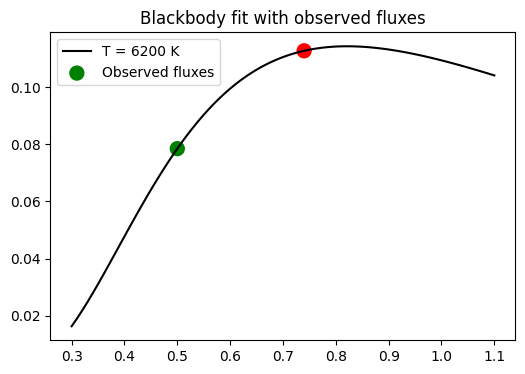

In [47]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6,4))
ax = plt.subplot(1, 1, 1)

_wl = np.linspace(0.3, 1.1, 100)
T = 6.209
ax.plot(_wl, blackbody(_wl, T), color='black', label='T = 6200 K')
ax.scatter([lsst_band_wl['g'], lsst_band_wl['i']], 
           [blackbody(lsst_band_wl['g'], T), 
            blackbody(lsst_band_wl['i'], T)], 
            c=['g', 'red'], s=100, label='Observed fluxes')
ax.legend()
ax.set_title('Blackbody fit with observed fluxes')

---




<h2 align="center"> How to Get Help </h2>

If you have a question or need any help, you can find past questions or as a new one on the **[Community Forum](https://community.lsst.org/c/support/support-lasair/55)**.


![communityforum](../tutorials/img/community_forum.png)